In [12]:
import pandas as pd
from nba_api.stats.endpoints import playergamelogs, teamgamelogs
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

# 1. Pull down individual Player Base Stats (Provides your 'REB' target)
player_logs = playergamelogs.PlayerGameLogs(
    season_nullable="2024-25",
    season_type_nullable="Regular Season"
)
player_df = player_logs.get_data_frames()[0]

# 2. Pull down Team Advanced Stats (Provides your 'PACE' environment feature)
team_logs = teamgamelogs.TeamGameLogs(
    season_nullable="2024-25",
    season_type_nullable="Regular Season",
    measure_type_player_game_logs_nullable="Advanced" 
)
team_pace_df = team_logs.get_data_frames()[0]

# 3. Create your clean, isolated lookup slice
pace_lookup = team_pace_df[['GAME_ID', 'TEAM_ID', 'PACE']]

# 4. Perform the left-join using your separate player data frame
final_df = pd.merge(player_df, pace_lookup, on=['GAME_ID', 'TEAM_ID'], how='left')

# 5. Build your clean 2-column analytic sandbox slice
pace_reb = final_df[["PACE", "REB"]]

Base Shape: (26306, 71)
Final Joined Shape: (26306, 71)
Missing Values:
 PACE    0
REB     0
dtype: int64


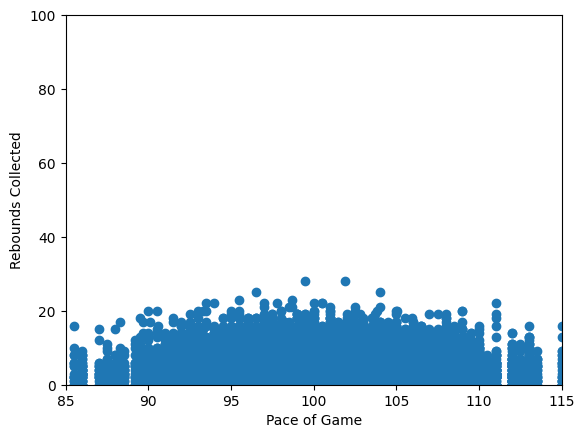

Correlation: 0.020110487568274184
R2 Score: 0.0004044317102339656


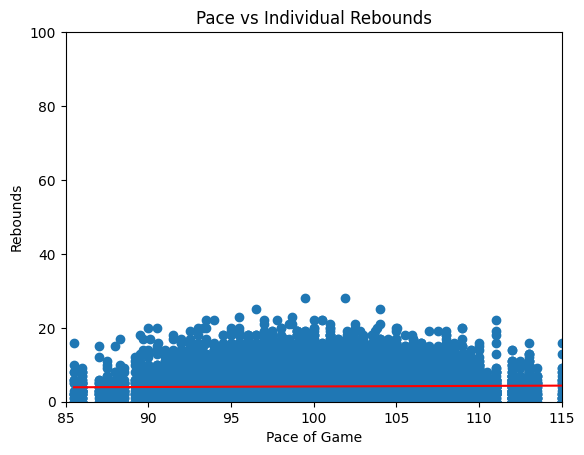

In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt


pace_reb = final_df[["PACE", "REB"]]

print("Base Shape:", final_df.shape)
print("Final Joined Shape:", final_df.shape)
print("Missing Values:\n", pace_reb.isnull().sum())

plt.scatter(pace_reb["PACE"], pace_reb["REB"])
plt.xlim(85, 115) # Adjusted boundaries to match real team-wide miss distributions
plt.ylim(0, 100)
plt.xlabel("Pace of Game")
plt.ylabel("Rebounds Collected")
plt.show()

print("Correlation:", pace_reb["PACE"].corr(pace_reb["REB"]))

# 5. Initialize, Fit, and Execute your Machine Learning Regression
X = pace_reb[["PACE"]]
y = pace_reb["REB"]

model = LinearRegression()
model.fit(X, y) # Fit the brain first!
r2 = model.score(X, y)
print("R2 Score:", r2)

# 6. Sort your feature matrix sequentially to draw a crisp trend line
X_sorted = X.sort_values("PACE")
predictions_sorted = model.predict(X_sorted)

# 7. Generate your final diagnostic report visualization
plt.scatter(pace_reb["PACE"], pace_reb["REB"])
plt.plot(X_sorted["PACE"], predictions_sorted, color="red") 

plt.xlim(85, 115)
plt.ylim(0, 100)
plt.xlabel("Pace of Game")
plt.ylabel("Rebounds")
plt.title("Pace vs Individual Rebounds")
plt.show()


In [ ]:
"""Feature: PACE (Game Pace / Total Possessions)

Relationship: 
Virtually non-existent direct linear relationship with individual REB.

Correlation: 
~0.020

R²: 
~0.0004

Why it matters / Basketball Logic: 
A massive data mining insight. Raw pace increases the total team-wide 
rebounding ecosystem volume, but it does not guarantee an individual player 
will harvest it unless controlled for court time. Because bench rows and 
superstar rows are mixed together, the raw linear relationship washes out.

Pregame usable? 
No, requires historical rolling matchup team projections.

Potential future use: 
High priority, but NOT as a standalone linear feature. Carry forward to use 
as a non-linear interaction multiplier combined with expected minutes to 
calculate true individual on-court opportunity volume.
"""